# Comparing the performance of various methods


### Import the required libraries and files


In [1]:
# Load ggplot2 first as it's a core dependency
library(ggplot2)
# Explicitly import ggproto
ggproto <- ggplot2::ggproto
Stat <- ggplot2::Stat

# Then load other visualization packages
library(plot3D)
library(tidyr)
library(tidyverse)
library(scales)
library(latex2exp)
library(cowplot)
library(ggh4x)
library(ggpubr)
library(gridExtra)
library(patchwork)
library(RColorBrewer)
library(stringr)
library(ggplotgui)
library(dplyr)

Warning message in fun(libname, pkgname):
"couldn't connect to display "/private/tmp/com.apple.launchd.YHbAcj0pMa/org.xquartz:0""
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v lubridate 1.9.4     v tibble    3.2.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x purrr::%||%()   masks base::%||%()
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: 'scales'


The following object is masked from 'package:purrr':

    discard


The following object is masked from 'package:readr':

    col_factor



Attaching package: 'cowplot'


The following object is masked from 'package:lubridate':

    stamp



Attaching package: 'ggpubr'


The following object is masked from 'package:c

In [2]:
nbfigsize <- function(width, height) {
    options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 300)
}

In [3]:
setwd(dirname(dirname(getwd())))

In [4]:
source("./MethodsEvaluation/results_processing_for_analysis.R")
source("./Pysindy/utils/pysindy_results_processing_for_analysis.R")

In [5]:
ggplot_3d_path <- "./R/ggplot2-3d"
load_r <- list.files(ggplot_3d_path, "*.R")
sapply(load_r, function(i) {
    source(paste0(ggplot_3d_path, "/", i))
})

axes_3D.R                                                                                                                                                                                                                                                                                                                                                             
value   function (mapping = aes(group = 1), data = NULL, geom = "path", ,     position = "identity", na.rm = FALSE, show.legend = NA, inherit.aes = TRUE, ,     ...) , {,     layer(stat = Axes3D, data = data, mapping = mapping, geom = geom, ,         position = position, show.legend = FALSE, inherit.aes = inherit.aes, ,         params = list(na.rm = na.rm, ...)), }
visible FALSE                                                                                                                                                                                                                                                                                                                                                                 
        axis_labs_3D.R                                                                                                                                                                                                                                                                                                                                                                            
value   function (mapping = aes(group = 1), data = NULL, geom = "text", ,     position = "identity", na.rm = FALSE, show.legend = NA, inherit.aes = TRUE, ,     ...) , {,     layer(stat = AxisLabels3D, data = data, mapping = mapping, ,         geom = geom, position = position, show.legend = FALSE, ,         inherit.aes = inherit.aes, params = list(na.rm = na.rm, ,             ...)), }
visible FALSE                                                                                                                                                                                                                                                                                                                                                                                     
        labs_3D.R                                                                                                                                                                                                                                                                                                                                                              
value   function (mapping = aes(group = 1), data = NULL, geom = "text", ,     position = "identity", na.rm = FALSE, show.legend = NA, inherit.aes = TRUE, ,     ...) , {,     layer(stat = Label3D, data = data, mapping = mapping, geom = geom, ,         position = position, show.legend = FALSE, inherit.aes = inherit.aes, ,         params = list(na.rm = na.rm, ...)), }
visible FALSE                                                                                                                                                                                                                                                                                                                                                                  
        stat_3D.R                                                                                                                                                                                                                                                                                                                                                    
value   function (mapping = NULL, data = NULL, geom = "point", position = "identity", ,     na.rm = FALSE, show.legend = NA, inherit.aes = TRUE, ...) , {,     layer(stat = Stat3D, data = data, mapping = mapping, geom = geom, ,         position = position, show.legend = show.legend, i

### General parameters settings


In [6]:
dynamical_system_name <- "rossler"
true_terms_1 <- list("x2", "x3")
true_terms_2 <- list("x1", "x2")
true_terms_3 <- list("(Intercept)", "x1x3", "x3")
true_terms_4 <- NULL

### Success rate generation for various number of observations n


#### Load the argos family algorithms results


In [7]:
root_path <- getwd()
experiment_name_list <- list("argos-alasso", "bayesian-alasso-ro")
method_list <- list("argos-alasso", "bayesian-alasso-ro")
function_number <- 3
exp_n <- TRUE
typical_pattern <- "snr49"
num_init <- 100
start <- 2
number_step <- 0.1

In [8]:
total_success_rate_table_n <- generate_total_success_rate_table(
    root_path = root_path,
    experiment_name_list = experiment_name_list,
    method_list = method_list,
    function_number = function_number,
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern,
    true_terms_1 = true_terms_1,
    true_terms_2 = true_terms_2,
    true_terms_3 = true_terms_3,
    true_terms_4 = true_terms_4,
    start = start,
    number_step = number_step
)

tail(total_success_rate_table_n)

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_1_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_1_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_1_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_2_e2_e3_bo2000_se100_alasso_ridge_snr49.RData"
[2] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_2_e3_e4_bo2000_se100_alasso_ridge_snr49.RData"
[3] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_2_e4_e5_bo2000_se100_alasso_ridge_snr49.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/co

Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_1_e2_e3_se100_snr49.RData"
[2] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_1_e3_e4_se100_snr49.RData"
[3] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_1_e4_e5_se100_snr49.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_2_e2_e3_se100_snr49.RData"
[2] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_2_e3_e4_se100_snr49.RData"
[3] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_2_e4_e5_se100_snr49.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_3_e2_

Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

,eta,Condition,Value,Model
,<dbl>,<chr>,<dbl>,<chr>
57,4.5,Correct,1,bayesian-alasso-ro
58,4.6,Correct,1,bayesian-alasso-ro
59,4.7,Correct,1,bayesian-alasso-ro
60,4.8,Correct,1,bayesian-alasso-ro
61,4.9,Correct,1,bayesian-alasso-ro
62,5.0,Correct,1,bayesian-alasso-ro


#### Load the pysindy algorithm results


In [9]:
pysindy_path <- file.path(getwd(), "Pysindy")

In [10]:
true_terms_1_py <- list("x1", "x2")
true_terms_2_py <- list("x0", "x1")
true_terms_3_py <- list("1", "x0 x2", "x2")
true_terms_4_py<- NULL

In [11]:
dynamics_identification_results_n <- check_dynamical_system_py(
    root_path = pysindy_path,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern,
    true_terms_1 = true_terms_1_py,
    true_terms_2 = true_terms_2_py,
    true_terms_3 = true_terms_3_py,
    true_terms_4 = true_terms_4_py,
    function_number = function_number
)

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Pysindy/exp/rossler/results/rossler_e2_e3_se100_snr49.RData"
[2] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Pysindy/exp/rossler/results/rossler_e3_e4_se100_snr49.RData"
[3] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Pysindy/exp/rossler/results/rossler_e4_e5_se100_snr49.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100


Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

In [12]:
pysindy_success_rate_table_n <- build_successful_rate_table_py(
    dynamics_identification_results = dynamics_identification_results_n,
    num_init = num_init,
    exp_n = exp_n,
    start = start,
    number_step = number_step,
    method = "pysindy"
)

In [13]:
total_success_rate_table_n <- rbind(total_success_rate_table_n, pysindy_success_rate_table_n)
total_success_rate_table_n <- rename_model_names(total_success_rate_table_n)
tail(total_success_rate_table_n)

,eta,Condition,Value,Model
,<dbl>,<chr>,<dbl>,<chr>
88,4.5,Correct,1,SINDy
89,4.6,Correct,1,SINDy
90,4.7,Correct,1,SINDy
91,4.8,Correct,1,SINDy
92,4.9,Correct,1,SINDy
93,5.0,Correct,1,SINDy


#### Plot the success rate for various n


##### General Plot settings for success rate


In [14]:
ggplot_theme0 <- theme(
    axis.line = element_line(colour = "black"),
    axis.ticks.length = unit(.25, "cm"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.border = element_blank(),
    panel.background = element_blank(),
    legend.key = element_blank(),
    legend.text = element_text(size = 20),
    # Changed for legend
    legend.title = element_text(face = "bold", size = 26),
    axis.text = element_text(size = 20),
    axis.title.x = element_text(size = 22),
    axis.title.y = element_text(
        size = 22,
        angle = 90,
        vjust = 0.5
    ),
    plot.title = element_text(size = 22),
    plot.tag = element_text(size = 28),
    legend.position = "none",
    legend.text.align = 0,
    plot.margin = margin(t = 0.75, r = 0.1, b = 0.25, l = 0.1, unit = "in")
)
ggplot_theme1 <- ggplot_theme0 + theme(plot.background = element_rect(fill = 0, colour = 0))

create_separators <- function(x, extra_x, y, extra_y, angle = 45, scale = 1, length = .1) {
    add_y <- length * sin(angle * pi / 180) / 2
    add_x <- length * cos(angle * pi / 180)
    list(
        x = x - add_x * scale, xend = x + add_x * scale + extra_x,
        y = rep(y - add_y * scale - extra_y, length(x)), yend = rep(y + add_y * scale - extra_y / 2, length(x))
    )
}

Warning message:
"The `legend.text.align` argument of `theme()` is deprecated as of ggplot2
3.5.0.
i Please use theme(legend.text = element_text(hjust)) instead."


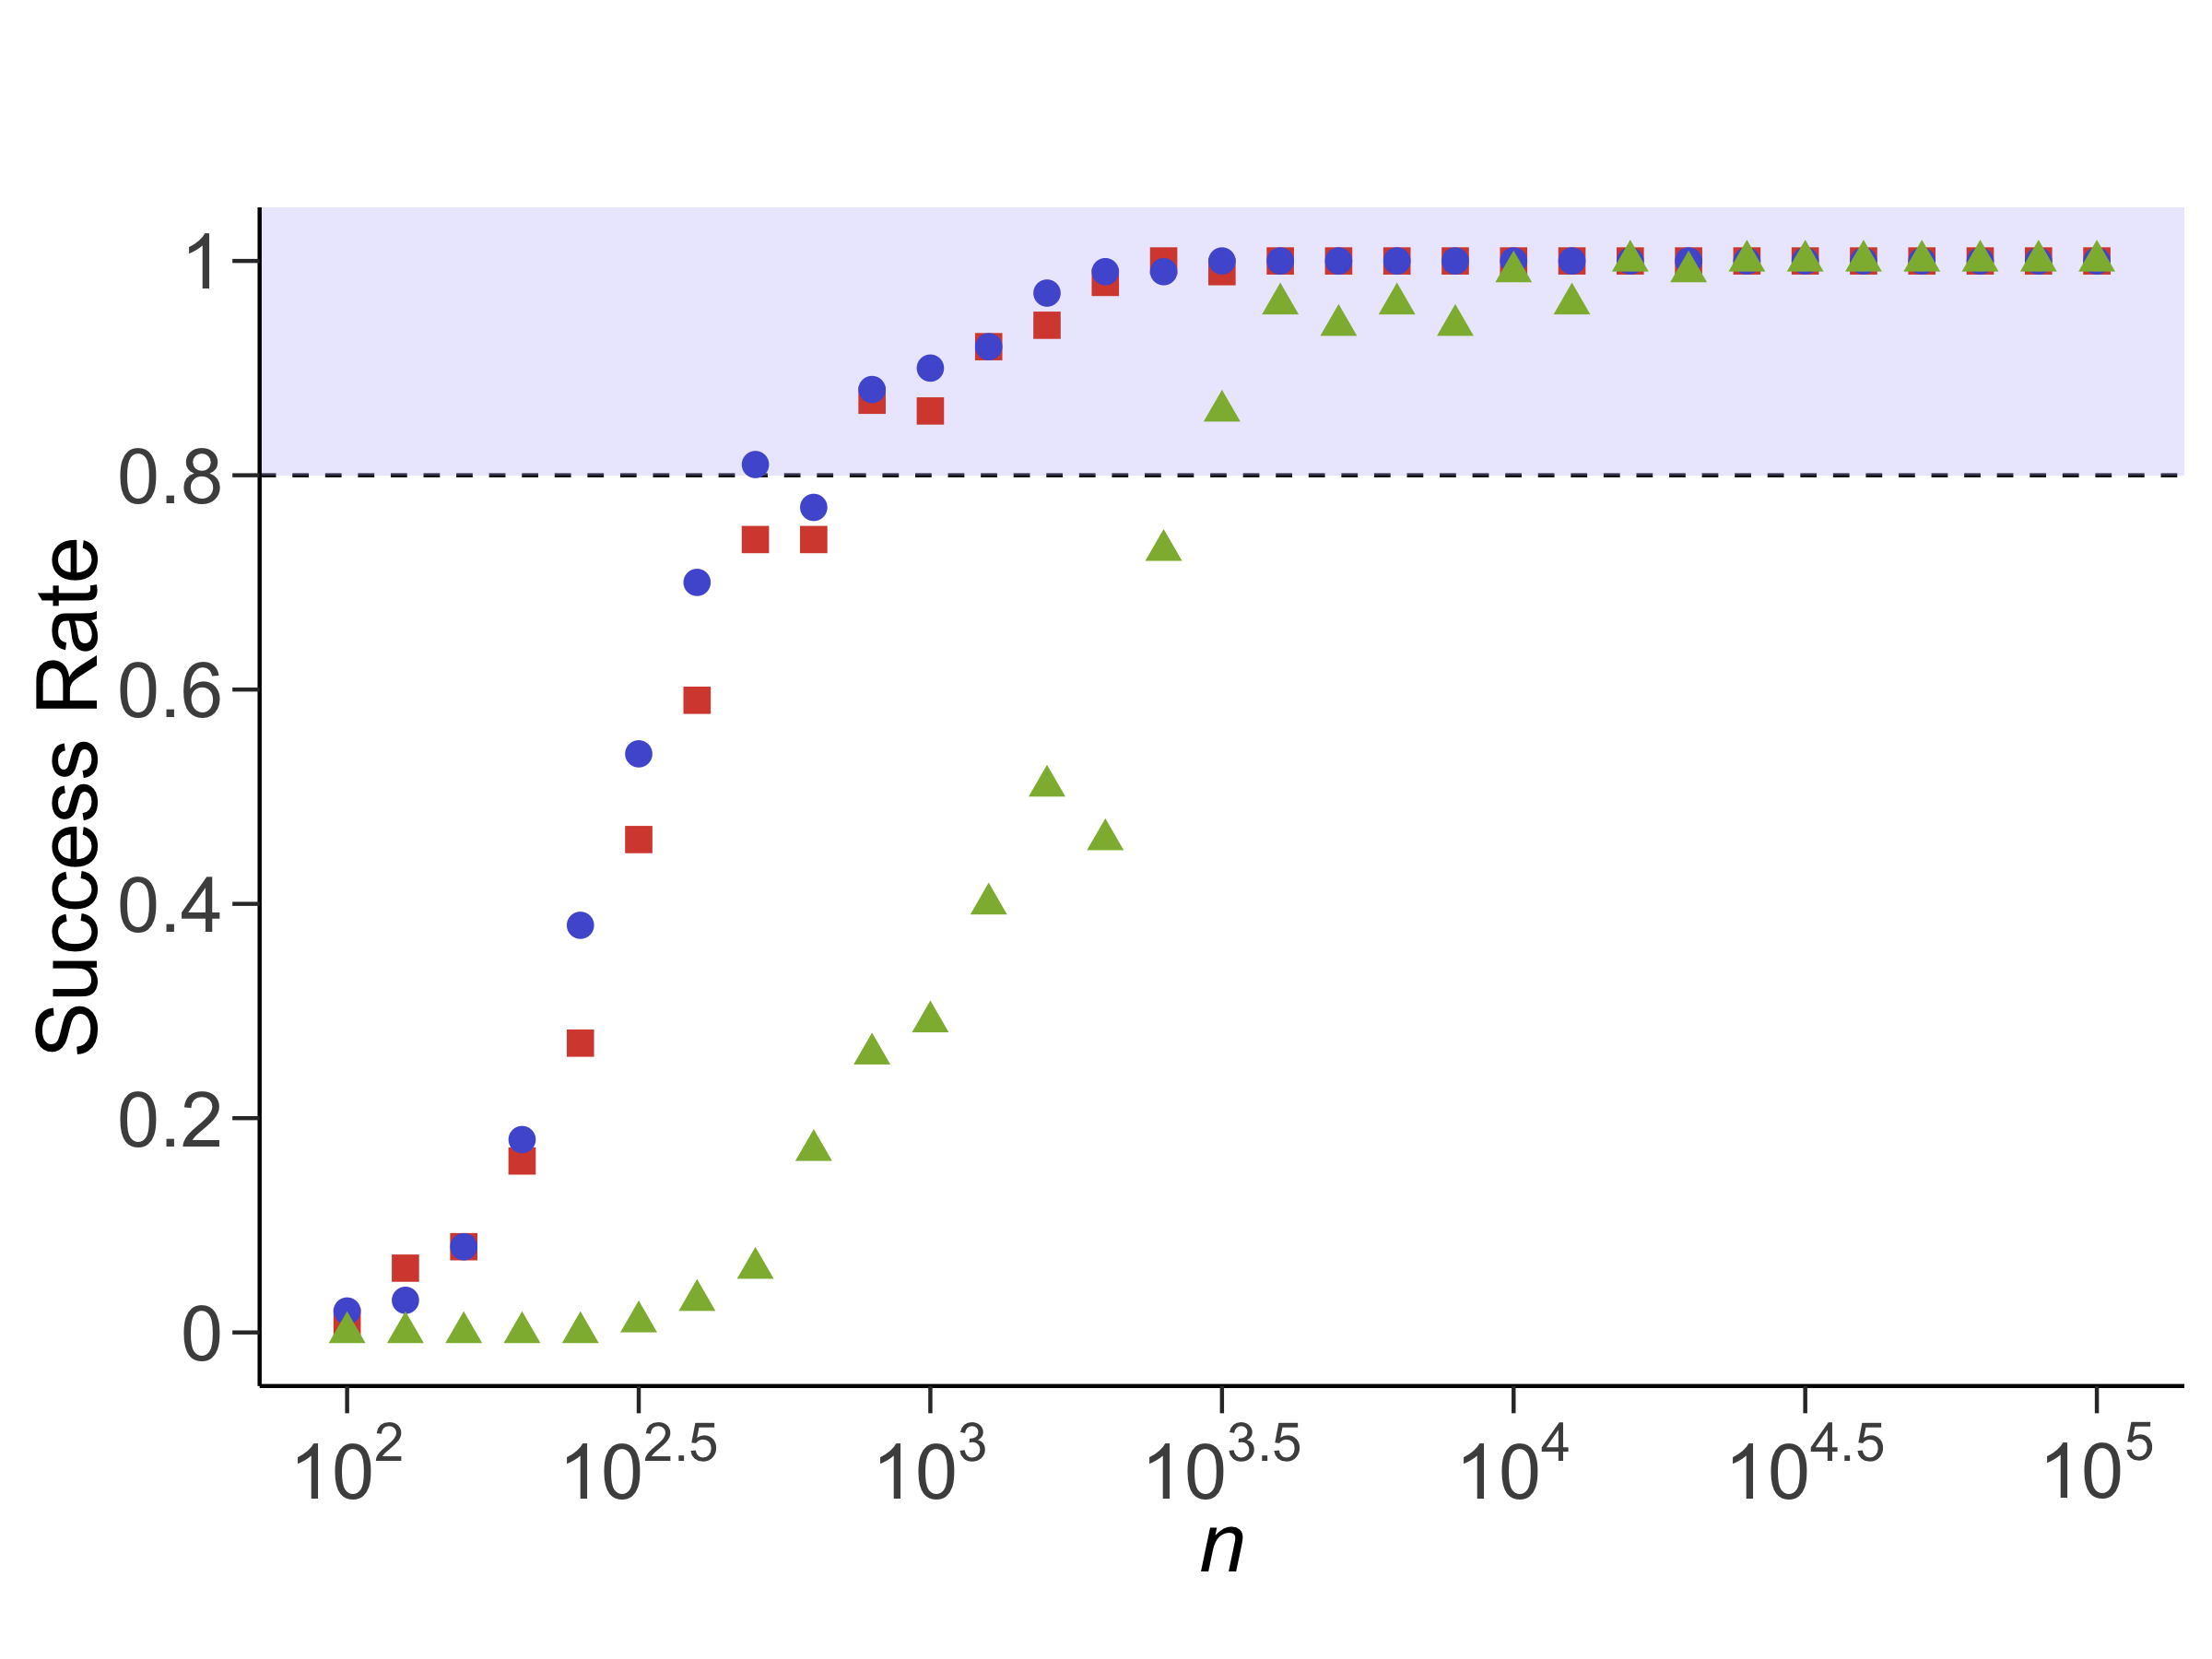

In [15]:
# - Parameters settings for success rate plot (N)
total_correct <- total_success_rate_table_n
models_name <- unique(total_correct$Model)
new_levels <- models_name[c(1, 2, 3, 4, 5)]
total_correct$Model <- factor(total_correct$Model, levels = new_levels)
n_seq <- seq(2, 5, by = 0.1)
rect1 <- data.frame(xmin = -Inf, xmax = Inf, ymin = 0.8, ymax = Inf)
colors_correct <- c("#d74d3d", "#505ed5", "#8eb63d", "#FA5524", "#EF60AD")
shapes <- c(15, 16, 17, 18, 19)

x_labels <- c(
    expression(paste("10"^"2")),
    expression(paste("10"^"2.5")),
    expression(paste("10"^"3")),
    expression(paste("10"^"3.5")),
    expression(paste("10"^"4")),
    expression(paste("10"^"4.5")),
    expression(paste("10"^"5"))
)

x_breaks <- pretty_breaks()(n_seq)
y_breaks <-
    y_labels <- pretty_breaks()(c(0, max(total_correct$Value)))

prob_increase_n <-
    ggplot() +
    geom_hline(yintercept = 0.8, lty = 2) +
    geom_rect(data = rect1, aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax), alpha = 0.3, fill = "#BDB6FB") +
    geom_point(
        data = total_correct,
        aes(
            x = eta,
            y = Value,
            fill = Model,
            col = Model,
            shape = Model
        ), size = 3
    ) +
    labs(
        y = "Success Rate",
        x = expression(italic("n"))
    ) +
    scale_x_continuous(
        labels = x_labels,
        breaks = x_breaks
    ) +
    scale_y_continuous(
        labels = y_labels,
        breaks = y_breaks,
        limits = c(0, max(y_labels))
    ) +
    ggplot_theme1 +
    # labs(title = paste(dynamical_system_name), tag = "a") +
    # theme(legend.position = "bottom") +
    scale_fill_manual(values = colors_correct, breaks = models_name, labels = models_name) +
    scale_colour_manual(values = colors_correct, breaks = models_name, labels = models_name) +
    scale_shape_manual(values = shapes, breaks = models_name, labels = models_name)

nbfigsize(
    width = 8,
    height = 6
)

# system_n <- arrangeGrob(prob_increase_n)
# grid.arrange(system_n, ncol = 1)
prob_increase_n

### Success rate generation for various snr values


In [16]:
experiment_name_list <- list("argos-alasso", "bayesian-alasso-ro")
method_list <- list("argos-alasso", "bayesian-alasso-ro")
function_number <- 3
exp_n <- FALSE
typical_pattern <- "n5000"
num_init <- 100
start <- 1
number_step <- 1

# - Generate the total success rate table
total_success_rate_table_snr <- generate_total_success_rate_table(
    root_path = root_path,
    experiment_name_list = experiment_name_list,
    method_list = method_list,
    function_number = function_number,
    num_init = num_init,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern,
    true_terms_1 = true_terms_1,
    true_terms_2 = true_terms_2,
    true_terms_3 = true_terms_3,
    true_terms_4 = NULL,
    start = start,
    number_step = number_step
)

tail(total_success_rate_table_snr)

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_1_snr1_snr61_bo2000_se100_alasso_ridge_n5000.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_2_snr1_snr61_bo2000_se100_alasso_ridge_n5000.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/argos-alasso/rossler/results/rossler_3_snr1_snr61_bo2000_se100_alasso_ridge_n5000.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100
[1] 32
[1] 100
[1] 33
[1] 100
[1] 34
[1] 100
[1] 

Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_1_snr1_snr61_se100_n5000.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_2_snr1_snr61_se100_n5000.RData"
[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Experiments/bayesian-alasso-ro/rossler/results/rossler_3_snr1_snr61_se100_n5000.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100
[1] 32
[1] 100
[1] 33
[1] 100
[1] 34
[1] 100
[1] 35
[1] 100
[1] 36
[1] 100
[1] 37
[1] 100
[

Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

,snr,Condition,Value,Model
,<dbl>,<chr>,<dbl>,<chr>
119,57,Correct,1.00,bayesian-alasso-ro
120,58,Correct,1.00,bayesian-alasso-ro
121,59,Correct,1.00,bayesian-alasso-ro
122,60,Correct,1.00,bayesian-alasso-ro
123,61,Correct,1.00,bayesian-alasso-ro
124,62,Correct,0.26,bayesian-alasso-ro


In [17]:
dynamics_identification_results_snr <- check_dynamical_system_py(
    root_path = pysindy_path,
    dynamical_system_name = dynamical_system_name,
    exp_n = exp_n,
    typical_pattern = typical_pattern,
    true_terms_1 = true_terms_1_py,
    true_terms_2 = true_terms_2_py,
    true_terms_3 = true_terms_3_py,
    true_terms_4 = true_terms_4_py,
    function_number = function_number
)

[1] "/Users/yuzhengzhang/Desktop/Code/code-repos/Bayesian-ARGOS/Pysindy/exp/rossler/results/rossler_snr1_snr61_se100_n5000.RData"
[1] 1
[1] 100
[1] 2
[1] 100
[1] 3
[1] 100
[1] 4
[1] 100
[1] 5
[1] 100
[1] 6
[1] 100
[1] 7
[1] 100
[1] 8
[1] 100
[1] 9
[1] 100
[1] 10
[1] 100
[1] 11
[1] 100
[1] 12
[1] 100
[1] 13
[1] 100
[1] 14
[1] 100
[1] 15
[1] 100
[1] 16
[1] 100
[1] 17
[1] 100
[1] 18
[1] 100
[1] 19
[1] 100
[1] 20
[1] 100
[1] 21
[1] 100
[1] 22
[1] 100
[1] 23
[1] 100
[1] 24
[1] 100
[1] 25
[1] 100
[1] 26
[1] 100
[1] 27
[1] 100
[1] 28
[1] 100
[1] 29
[1] 100
[1] 30
[1] 100
[1] 31
[1] 100
[1] 32
[1] 100
[1] 33
[1] 100
[1] 34
[1] 100
[1] 35
[1] 100
[1] 36
[1] 100
[1] 37
[1] 100
[1] 38
[1] 100
[1] 39
[1] 100
[1] 40
[1] 100
[1] 41
[1] 100
[1] 42
[1] 100
[1] 43
[1] 100
[1] 44
[1] 100
[1] 45
[1] 100
[1] 46
[1] 100
[1] 47
[1] 100
[1] 48
[1] 100
[1] 49
[1] 100
[1] 50
[1] 100
[1] 51
[1] 100
[1] 52
[1] 100
[1] 53
[1] 100
[1] 54
[1] 100
[1] 55
[1] 100
[1] 56
[1] 100
[1] 57
[1] 100
[1] 58
[1] 100
[1] 59
[1

Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argument of type 'list' to logical"
Warning message in FUN(newX[, i], ...):
"coercing argu

In [18]:
pysindy_success_rate_table_snr <- build_successful_rate_table_py(
    dynamics_identification_results = dynamics_identification_results_snr,
    num_init = num_init,
    exp_n = exp_n,
    start = start,
    number_step = number_step,
    method = "pysindy"
)

head(pysindy_success_rate_table_snr)

,snr,Condition,Value,Model
,<dbl>,<chr>,<dbl>,<chr>
1,1,Correct,0.01,pysindy
2,2,Correct,0.02,pysindy
3,3,Correct,0.02,pysindy
4,4,Correct,0.03,pysindy
5,5,Correct,0.04,pysindy
6,6,Correct,0.03,pysindy


In [19]:
total_success_rate_table_snr <- rbind(total_success_rate_table_snr, pysindy_success_rate_table_snr)
total_success_rate_table_snr <- rename_model_names(total_success_rate_table_snr)
tail(total_success_rate_table_snr)

,snr,Condition,Value,Model
,<dbl>,<chr>,<dbl>,<chr>
181,57,Correct,0.97,SINDy
182,58,Correct,0.97,SINDy
183,59,Correct,0.98,SINDy
184,60,Correct,0.98,SINDy
185,61,Correct,0.98,SINDy
186,62,Correct,0.86,SINDy


#### Plot the success rate based on various snr


Warning message:
"`guide_axis_truncated()` was deprecated in ggh4x 0.3.0.
i Please use `ggplot2::guide_axis(cap = TRUE)` instead."
Warning message:
"The S3 guide system was deprecated in ggplot2 3.5.0.
i It has been replaced by a ggproto system that can be extended."


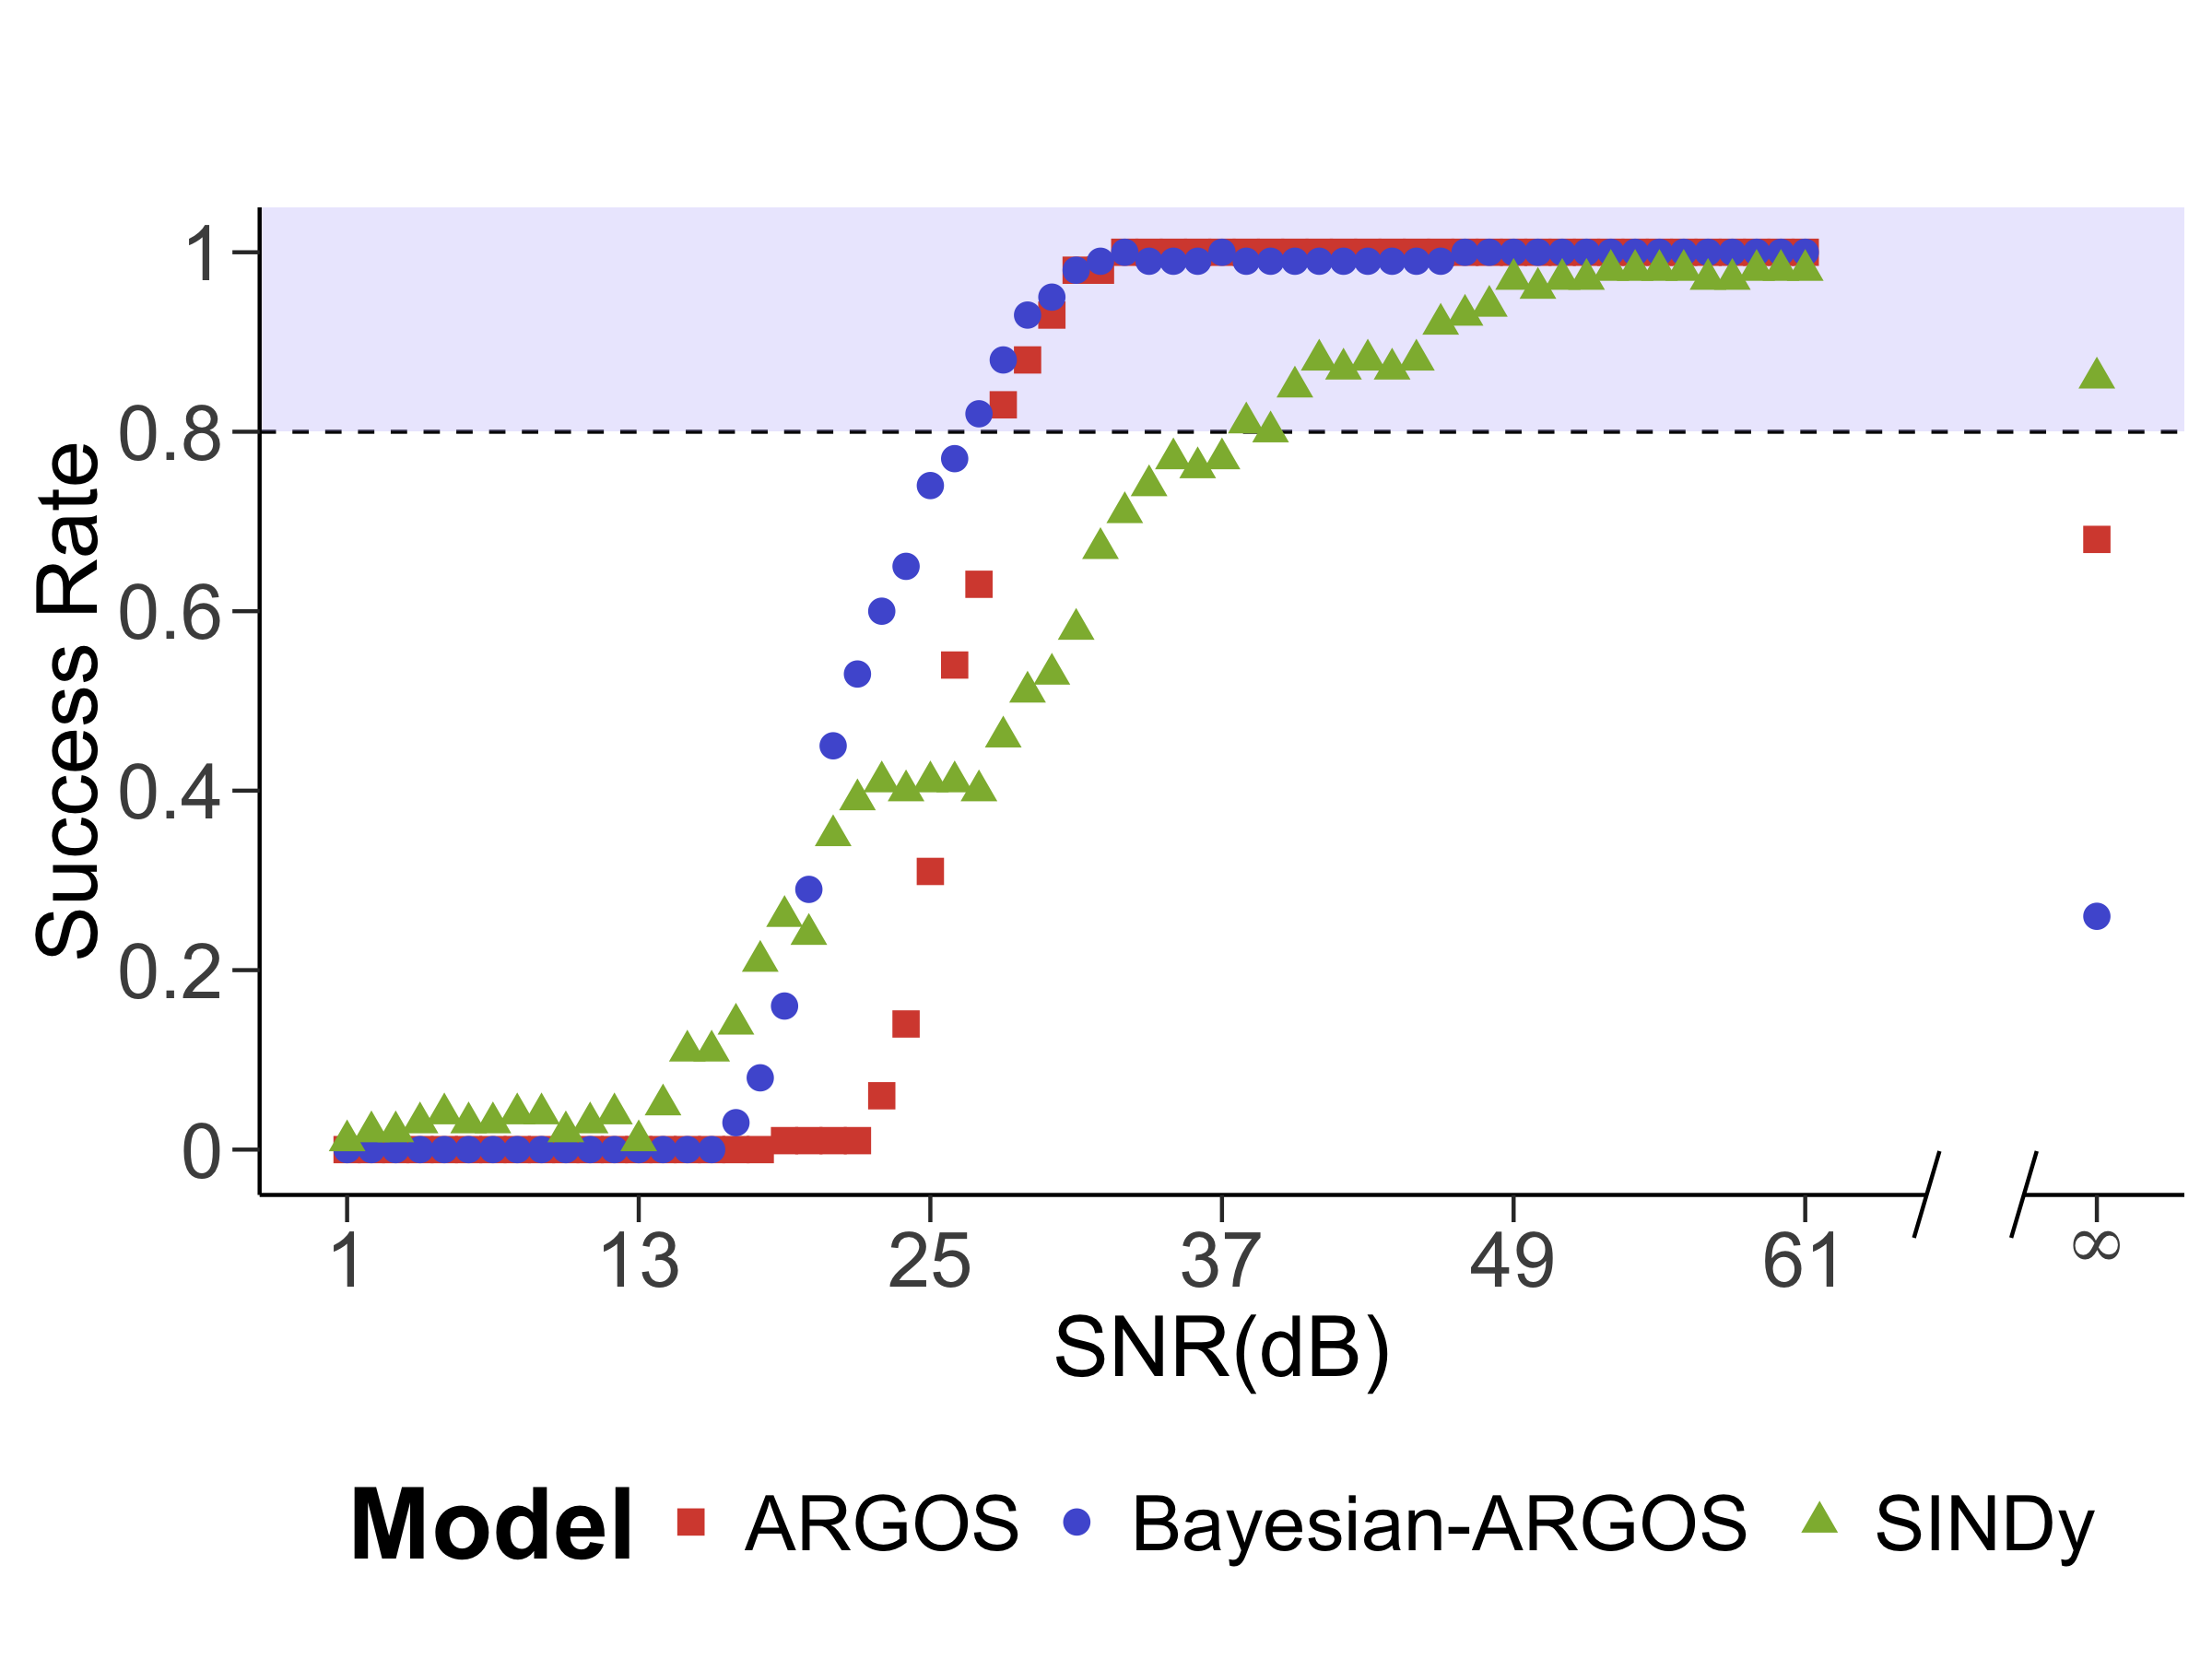

In [20]:
colors_correct <- c("#d74d3d", "#505ed5", "#8eb63d", "#FA5524", "#EF60AD")
shapes <- c(15, 16, 17, 18, 19)
rect1 <- data.frame(xmin = -Inf, xmax = Inf, ymin = 0.8, ymax = Inf)

total_correct <- total_success_rate_table_snr
for (i in seq(62, nrow(total_correct), 62)) {
    total_correct$snr[i] <- 73
}
models_name <- unique(total_correct$Model)
new_levels <- models_name[c(1, 2, 3, 4, 5)]
total_correct$Model <- factor(total_correct$Model, levels = new_levels)
# total_correct <- arrange(total_correct, Model)
# models_name <- new_levels[c(1, 2)]

x_labels <- x_breaks <- seq(1, 73, by = 12)
x_labels[length(x_labels)] <- TeX("$\\infty$")

y_labels <-
    y_breaks <-
    pretty_breaks()(c(min(total_correct$Value), max(total_correct$Value)))

xstart <- 65.5
xend <- 69.5
extra_x <- 1
y_sep <- min(total_correct$Value) - 0.05 * (min(total_correct$Value))
myseg <- create_separators(c(xstart, xend), extra_x = 1, y = y_sep, extra_y = 0.1, angle = 75)

prob_increase_snr <-
    ggplot() +
    geom_hline(yintercept = 0.8, lty = 2) +
    geom_rect(data = rect1, aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax), alpha = 0.3, fill = "#BDB6FB") +
    geom_point(
        data = total_correct,
        aes(
            x = snr,
            y = Value,
            fill = Model,
            col = Model,
            shape = Model
        ), size = 3
    ) +
    labs(
        y = "Success Rate",
        x = TeX("SNR(dB)")
    ) +
    scale_x_continuous(
        limits = c(
            min(x_breaks),
            max(x_breaks)
        ),
        labels = x_labels,
        breaks = x_breaks
    ) +
    scale_y_continuous(
        labels = y_labels,
        breaks = y_breaks,
        limits = c(NA, max(y_breaks))
    ) +
    ggplot_theme1 +
    # labs(title = paste(dynamical_system_name), tag = "b") +
    theme(legend.position = "bottom") +
    scale_fill_manual(values = colors_correct, breaks = models_name, labels = models_name) +
    scale_colour_manual(values = colors_correct, breaks = models_name, labels = models_name) +
    scale_shape_manual(values = shapes, breaks = models_name, labels = models_name) +
    guides(x = guide_axis_truncated(
        trunc_lower = c(-Inf, xend + extra_x / 2),
        trunc_upper = c(xstart + extra_x / 2, Inf)
    )) +
    annotate("segment",
        x = myseg$x, xend = myseg$xend,
        y = myseg$y + 0.05, yend = myseg$yend
    ) +
    coord_cartesian(clip = "off", ylim = c(-0.0005, NA))

# prob_increase_snr + labs(title = paste(dynamical_system_name), tag = "b") + theme(legend.position = "bottom")
prob_increase_snr

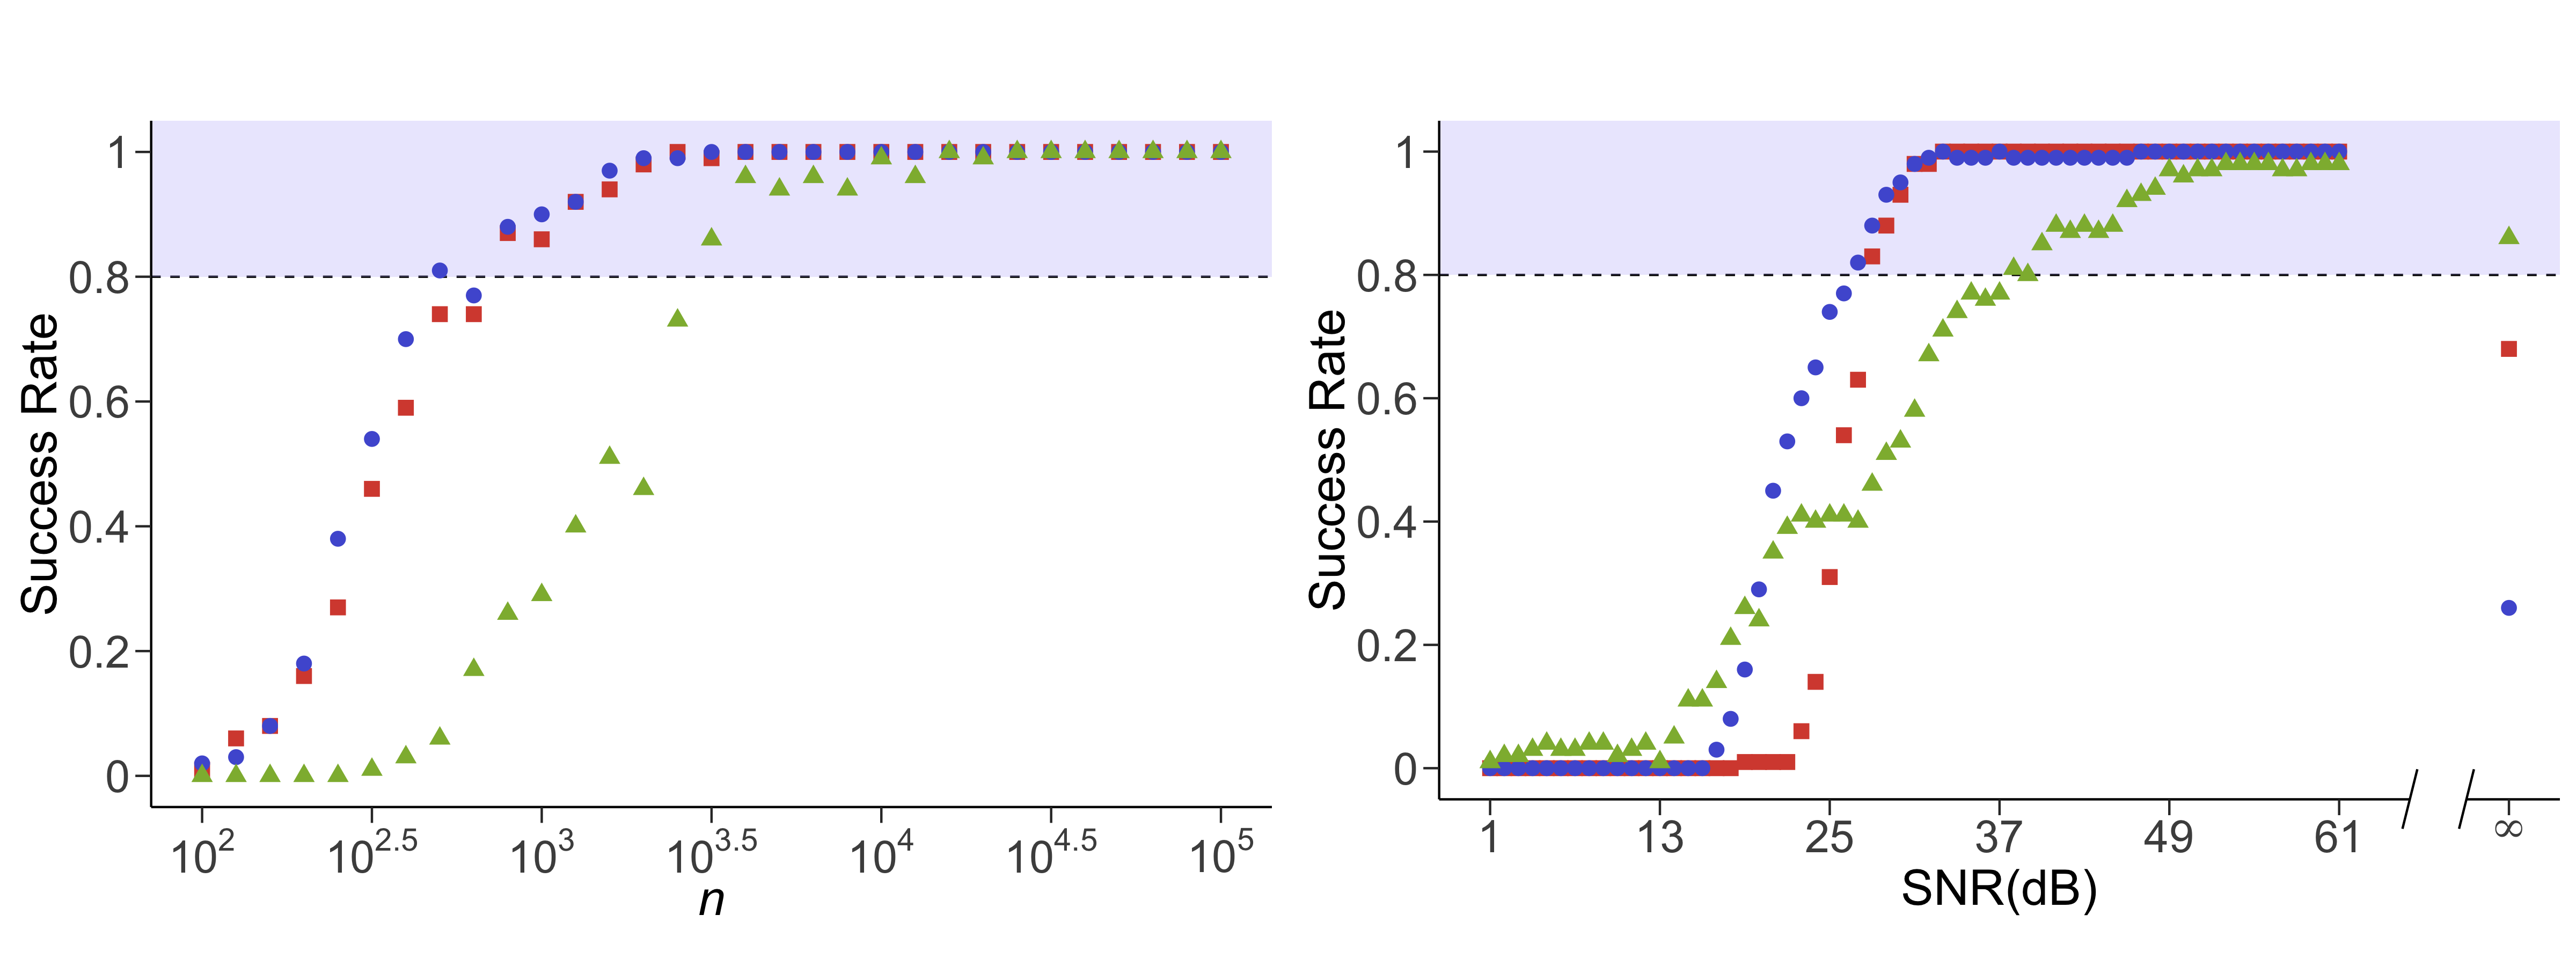

In [21]:
gglegend <- get_legend(prob_increase_snr)

# grid.arrange(system_n, ncol = 1)
system_comprehensive <-
    arrangeGrob(prob_increase_n + theme(legend.position = "none"),
        prob_increase_snr + theme(legend.position = "none"),
        # runtime_ggplot + theme(legend.position = "none"),
        nrow = 1
    )
nbfigsize(
    width = 16,
    height = 6
)
# system_comprehensive <- grid.arrange(system_comprehensive, gglegend, ncol = 1, heights = c(15, 1))
system_comprehensive <- grid.arrange(system_comprehensive, ncol = 1, heights = c(16, 0))
ggsave(plot = system_comprehensive, filename = sprintf(
        "./ResultsAnalysis/success-rate-plots/imgs/%s_success_rate_plot.pdf",
        dynamical_system_name
    ), width = 16, height = 6, dpi = 600, units = "in")
